## 1. 练习线性回归之梯度下降，Lasso回归，岭回归，理解原理是核心

In [23]:
import pandas as pd  # 导入pandas用于数据处理
from sklearn.datasets import fetch_california_housing  # 导入scikit-learn中加州房价数据集的下载工具

# 使用fetch_california_housing从本地或网络下载加利福尼亚房价数据
# data变量是一个Bunch对象，类似于字典，包含了data（特征），target（标签），feature_names，DESCR等信息
data = fetch_california_housing(data_home='data')  # data_home指定数据保存路径

# 将获取到的特征数据(data.data)转为DataFrame格式，方便分析与处理
# columns参数指定每列的名称，对应于data.feature_names
df = pd.DataFrame(data.data, columns=data.feature_names)

# 将目标变量（即房价）加入到DataFrame作为新的一列，提高数据的完备性
# data.target即为每个数据点对应的房价中位数
df['price'] = data.target

# 展示DataFrame的前5行数据，初步查看数据结构和内容
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
from sklearn.model_selection import train_test_split
import numpy as np

# 分割特征和标签，X为特征，y为目标变量
X = df.drop('price', axis=1).values  # 删除price列，剩余列作为特征
y = df['price'].values               # price列作为标签
print(y.shape)                       # 打印标签y的形状，主要用于检查数据完整性

# 划分训练集和测试集。test_size=0.2表示20%作为测试集，random_state确保可重复性
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 测试集占比20%
    random_state=42       # 随机种子，保证结果可复现
)

from sklearn.preprocessing import StandardScaler

# 对特征数据进行标准化处理，使其均值为0，方差为1，有助于加快模型收敛速度与提升精度
scaler = StandardScaler()            # 实例化标准化器
X_train = scaler.fit_transform(X_train)  # 用训练集估算参数并标准化训练集数据
X_test = scaler.transform(X_test)        # 用训练集的标准化参数对测试集进行相同的变换

from sklearn.linear_model import LinearRegression

# 创建线性回归模型实例
lr = LinearRegression()
# 用训练集数据拟合（训练）线性回归模型，找到最优参数
lr.fit(X_train, y_train)

# 打印线性回归模型的回归系数和截距项
# 回归系数表示每个特征对预测目标的影响
print("回归系数:", lr.coef_)
print("截距项:", lr.intercept_)

# 使用训练好的线性回归模型对测试集数据进行预测
y_pred = lr.predict(X_test)

# 评估模型性能：使用均方误差（MSE），衡量预测值与实际值之间的差异
mse = np.mean((y_pred - y_test) ** 2)
print(f"正规方程测试集均方误差 MSE: {mse}")


(20640,)
回归系数: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
截距项: 2.071946937378619
正规方程测试集均方误差 MSE: 0.5558915986952442


In [25]:
from sklearn.linear_model import SGDRegressor

# SGDRegressor是使用随机梯度下降法（Stochastic Gradient Descent）的线性回归模型。
# 它通过每次用部分样本数据进行参数更新，来加速大规模数据的训练效率。

# 参数说明（此处为本例设定）:
# eta0=0.01     ：设置初始学习率（learning rate），控制每次参数更新的步长大小；
#                 较大时模型收敛快但可能不稳定，过小时收敛慢。
# penalty='l2'  ：使用L2正则化，即岭回归，通过惩罚大系数，防止模型过拟合；
#                 可选择'l1'（Lasso，产生稀疏解），'elasticnet'（组合L1和L2）。
# max_iter=1000 ：最大迭代次数，即参数更新的最大轮数
#                 若提前收敛，则会提前停止。

# SGDRegressor还有学习率schedule:
# learning_rate (默认'optimal')：控制学习率更新方式，包括constant、optimal、invscaling、adaptive。
# 例如'invscaling'（按步数递减学习率），'constant' (恒定学习率)，
# 'adaptive'（根据是否收敛调整学习率）等。
# 另外参数alpha用于调节正则化的强度，值越大正则化越强。

sgd_reg = SGDRegressor(eta0=0.01, penalty='l2', max_iter=1000)

# 用训练集数据拟合（训练）SGD线性回归模型，寻找最优参数
sgd_reg.fit(X_train, y_train)

# 输出模型的回归系数（每个特征对应的权重），衡量每个特征对目标值的影响程度
print("SGD回归系数:", sgd_reg.coef_)
# 输出截距项，即在所有特征为0时模型预测的常数项
print("SGD截距项:", sgd_reg.intercept_)

# 用训练好的模型对测试集进行预测，获得测试集样本的价格预测值
y_pred_sgd = sgd_reg.predict(X_test)

# 用均方误差（MSE）评估回归模型在测试集的性能，即预测结果与实际结果的平均平方差
mse_sgd = np.mean((y_pred_sgd - y_test) ** 2)
print(f"SGDRegressor测试集均方误差 MSE: {mse_sgd}")


SGD回归系数: [ 7.95774454e-01  1.14127089e-01 -1.93096459e-01  2.65542589e-01
 -6.35802574e-04 -2.11475672e-01 -1.00495618e+00 -9.92062946e-01]
SGD截距项: [2.07579942]
SGDRegressor测试集均方误差 MSE: 0.5504793241617233


In [26]:
from sklearn.linear_model import Lasso

# 创建Lasso回归模型实例
# alpha参数用于控制L1正则化的强度，值越大则惩罚越强，更多系数会被压缩为零，从而达到特征选择和防止过拟合的效果
lasso_reg = Lasso(alpha=0.001)

# 用训练集数据拟合（训练）Lasso回归模型，自动寻找最合适的回归系数
# 拟合过程通过最小化带L1正则化项的损失函数来实现
lasso_reg.fit(X_train, y_train)

# 输出模型的回归系数（每个特征对应的权重），可以分析哪些特征被Lasso选择为显著变量
# Lasso有特征选择的效果，部分系数可能被压缩为0
print("Lasso回归系数:", lasso_reg.coef_)

# 用训练好的模型对测试集数据进行预测，得到测试集样本的房价预测值
y_pred_lasso = lasso_reg.predict(X_test)

# 用均方误差（MSE）评估Lasso回归模型在测试集上的性能，衡量预测值和真实值的平均平方差
mse_lasso = np.mean((y_pred_lasso - y_test) ** 2)
print(f"Lasso回归测试集均方误差 MSE: {mse_lasso}")


Lasso回归系数: [ 0.84914038  0.12334631 -0.28127333  0.32604963 -0.00106185 -0.03988954
 -0.88582217 -0.85809324]
Lasso回归测试集均方误差 MSE: 0.5544913600832686


In [27]:
np.random.seed(22)
# 1. 准备数据X,y 增加噪声
# 创建100个数据,在[-3,3]中取值,值是均匀分布的
x = np.random.uniform(-3, 3, size=100)
x

array([-1.74923678, -0.10991363, -0.47677179,  2.15509199, -1.97303068,
       -0.96681624, -1.376803  ,  1.1462481 , -1.6775729 ,  1.87170552,
       -2.93683875,  0.36722218,  1.88235712,  1.47060178, -1.86533187,
       -2.9631548 ,  1.63226323,  2.74699301,  1.2116273 , -1.2145304 ,
        1.60795645,  1.12930995, -0.67689912,  0.69123495, -0.43466856,
        0.50573786,  1.21581311, -2.32862897,  2.53961956,  2.93331764,
        1.06446464,  1.77098865, -2.8255419 , -1.93344557,  2.24956647,
        1.46959246,  0.04854098, -2.22999659, -0.09429457,  0.09464093,
       -1.13241202, -2.72603074, -0.37391604, -2.42469234, -2.72873933,
        1.10897231,  2.09514447, -2.2487569 , -2.22561596, -0.16163999,
       -1.81464895,  1.68973649,  0.64448318, -0.33899943,  2.89217465,
        1.25373248, -1.68761751, -1.99507021,  0.23259284, -1.11947527,
        2.46922198, -2.48246592, -1.11555582, -1.68517583,  1.41999738,
        1.97124219,  1.46738678, -1.93477777,  2.15071918, -2.96

原始1阶特征X的形状: (100, 1)
多项式特征扩展后X2的形状: (100, 10)
Ridge回归MSE（均方误差）: 0.8340220252344763
Ridge回归权重w（各阶多项式系数）: [ 9.61199650e-01  1.03752625e+00 -4.41366376e-01 -2.45484025e-01
  2.81460639e-01  3.49426802e-02 -5.58289858e-02 -5.58964522e-05
  3.38758035e-03 -1.84530373e-04]


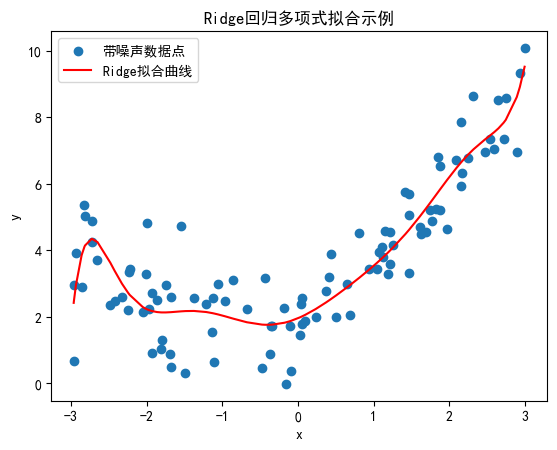

array([ 9.61199650e-01,  1.03752625e+00, -4.41366376e-01, -2.45484025e-01,
        2.81460639e-01,  3.49426802e-02, -5.58289858e-02, -5.58964522e-05,
        3.38758035e-03, -1.84530373e-04])

In [28]:
# 岭回归（Ridge Regression）：用于解决特征多重共线性或防止过拟合的线性模型，带L2正则化项
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

# 1. 创建数据
# 设置随机种子，保证结果可复现
np.random.seed(22)

# 创建100个均匀分布在[-3,3]区间上的自变量x（一维数组）
x = np.random.uniform(-3, 3, size=100)

# 构造目标变量y，y满足二次函数关系，并叠加均值为0、方差为1的高斯噪声
# 这样可以更加接近真实场景的数据分布
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, size=100)

# 2. 创建岭回归模型实例
# Ridge()的alpha参数默认为1.0，表示L2正则化的强度，可以调整控制正则化力度
model = Ridge()

# 3. 数据准备及模型训练
# 机器学习模型通常需要输入二维特征数组，因此将x重塑为n行1列（二维）
# reshape(-1,1)中的-1让numpy自动计算行数，以保持数据总长度不变
X = x.reshape(-1, 1)
print("原始1阶特征X的形状:", X.shape)

# 生成多项式特征（x, x^2, ..., x^10），通过hstack堆叠在一起
# 这样可以使模型拟合更复杂的函数关系，增强模型表达能力
X2 = np.hstack([
    X,
    X ** 2,
    X ** 3,
    X ** 4,
    X ** 5,
    X ** 6,
    X ** 7,
    X ** 8,
    X ** 9,
    X ** 10
])
print("多项式特征扩展后X2的形状:", X2.shape)

# 用扩展后的多项式特征X2和目标y训练岭回归模型，拟合多项式回归关系
model.fit(X2, y)

# 4. 用训练好的模型进行预测，得到y的拟合值
y_predict = model.predict(X2)

# 5. 评估模型效果
# 用均方误差（MSE）衡量岭回归的拟合效果，值越小表示模型预测越准确
mse = mean_squared_error(y, y_predict)
print("Ridge回归MSE（均方误差）:", mse)
# 输出回归模型的各阶多项式特征的权重系数
print("Ridge回归权重w（各阶多项式系数）:", model.coef_)

# 6. 绘制散点图和拟合曲线
# 绘制原始带噪声的数据点，图中蓝色圆点
plt.scatter(x, y, label='带噪声数据点')
# 为了画出平滑的拟合曲线，对x进行排序，并根据排序后的索引对应y_predict进行绘制
plt.plot(np.sort(x), y_predict[np.argsort(x)], color='r', label='Ridge拟合曲线')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ridge回归多项式拟合示例')
plt.legend()
plt.show()

# 显示模型的系数
model.coef_

原始特征X的形状: (100, 1)
多项式特征扩展后X2的形状: (100, 10)
线性回归MSE: 0.8144736129032126
线性回归权重w: [ 1.48390146e+00  1.91708406e+00 -1.09189930e+00 -9.60331272e-01
  5.22612600e-01  2.48127460e-01 -9.01884785e-02 -2.65810071e-02
  5.04735223e-03  9.83074618e-04]


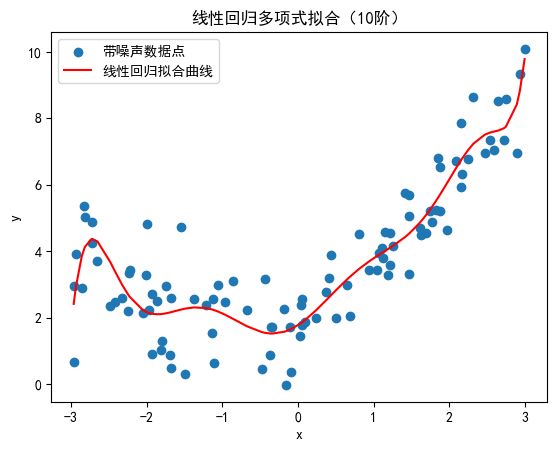

array([ 1.48390146e+00,  1.91708406e+00, -1.09189930e+00, -9.60331272e-01,
        5.22612600e-01,  2.48127460e-01, -9.01884785e-02, -2.65810071e-02,
        5.04735223e-03,  9.83074618e-04])

In [29]:
# 2. 创建模型
# 使用线性回归（普通最小二乘法），此处不加任何正则化项
from sklearn.linear_model import LinearRegression
model = LinearRegression()   # 实例化一个线性回归模型对象

# 3. 模型训练
# 训练数据要求二维，所以需要将原始特征x（shape为[N,]，即一维数组）reshape成二维（shape:[N,1]）
# reshape(-1, 1)：-1让numpy自动计算一维的长度，1表示每行为1列
X = x.reshape(-1,1)
print("原始特征X的形状:", X.shape)   # 输出变形后的X的形状，便于确认

# 堆叠，扩展多项式特征将模型从线性提升为高阶多项式（10阶）
# np.hstack将每一阶x（x^1、x^2、...、x^10）逐列堆叠，生成一个新的特征矩阵X2
X2 = np.hstack([X, 
                X ** 2, 
                X ** 3,
                X ** 4,
                X ** 5,
                X ** 6,
                X ** 7,
                X ** 8,
                X ** 9,
                X ** 10])
print("多项式特征扩展后X2的形状:", X2.shape)  # 检查特征扩展后数组形状

# 用扩展后的多项式特征X2与目标变量y训练模型，拟合相应的多项式关系
model.fit(X2, y)

# 4. 模型预测
# 使用训练好的模型对输入X2进行预测，得到y的拟合值
y_predict = model.predict(X2)

# 5. 模型评估
# 使用均方误差（MSE）评价预测效果，数值越小模型预测越准确
mse = mean_squared_error(y, y_predict)
print("线性回归MSE:", mse)
# 输出多项式回归模型的所有权重（系数），即各阶项的权重
print("线性回归权重w:", model.coef_)

# 6. 绘制图像：可视化原始数据点与拟合曲线
plt.scatter(x, y, label="带噪声数据点")   # 原始带噪声数据，散点图
# 画拟合曲线：x需要排序，y_predict需对应x的排序顺序，否则连接线杂乱
plt.plot(np.sort(x), 
         y_predict[np.argsort(x)], 
         color='r', 
         label="线性回归拟合曲线")
plt.xlabel("x")
plt.ylabel("y")
plt.title("线性回归多项式拟合（10阶）")
plt.legend()    # 添加图例
plt.show()

# 输出模型权重（可在notebook里直接显示，供进一步分析）
model.coef_

## 2. 实战逻辑回归案例，调整参数，感受准确率变化

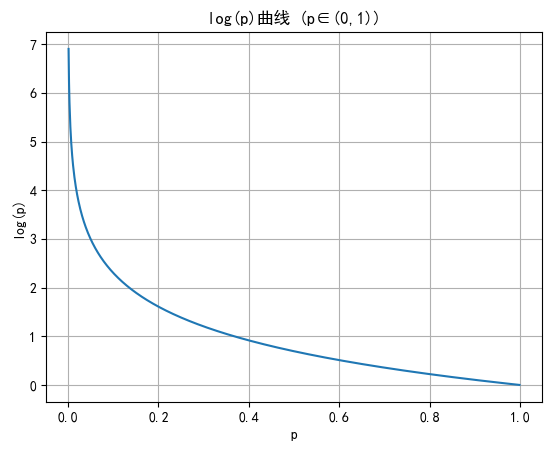

In [30]:
# 真实值为1类别时的loss曲线（-log(p)），用于逻辑回归中损失函数的理解

import numpy as np
import matplotlib.pyplot as plt

# 生成概率p的取值范围: 从0.001到0.999均匀取1000个点
# 这里不取0和1，避免log(0)或log(1)导致无穷大或无定义
p = np.linspace(0.001, 0.999, 1000)  

# 计算交叉熵损失（真实标签为1时）：-log(p)
logp = -np.log(p)

# 绘制p与-log(p)的关系曲线
plt.plot(p, logp)

# 设置x轴的标签，表示概率p
plt.xlabel('p')
# 设置y轴的标签，表示-log(p)损失
plt.ylabel('log(p)')

# 设置中文字体为黑体，保证标题和标签能够正确显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']
# 设置正常显示负号
plt.rcParams['axes.unicode_minus'] = False    

# 设置图表标题
plt.title('log(p)曲线 (p∈(0,1))')

# 添加网格以便观察曲线细节
plt.grid(True)

# 显示绘制的图形
plt.show()


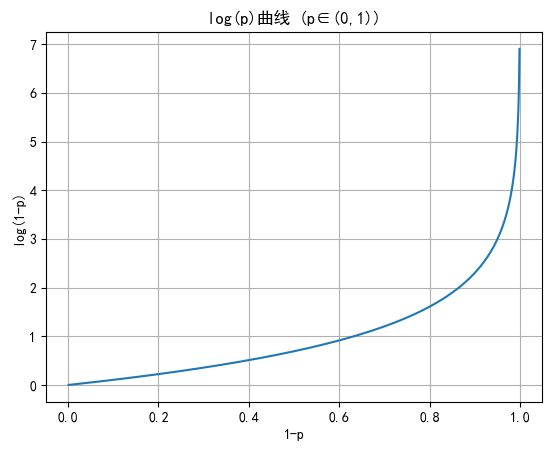

In [31]:
# 真实标签为0类别时的损失函数曲线绘制
import numpy as np
import matplotlib.pyplot as plt

# 生成概率p的取值范围: 从0.001到0.999，等间隔取1000个点
# 注意不取0和1是为了避免log(0)出现无穷或出错
p = np.linspace(0.001, 0.999, 1000)  

# 计算交叉熵损失（真实标签为0的情况）: -log(1-p)
# 损失函数反映了预测p越接近于1时，误判为1的损失越大
logp = -np.log(1-p)

# 设置中文显示为黑体，避免中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  
# 设置正常显示负号
plt.rcParams['axes.unicode_minus'] = False    

# 绘制概率p与-log(1-p)的关系曲线
plt.plot(p, logp)

# 设置x轴标签，理论上应为p（预测为1的概率）
# 但这里xlabel设置为'1-p'其实可以理解为“预测为0的概率”
plt.xlabel('1-p')

# 设置y轴标签，表示-log(1-p)损失函数值
plt.ylabel('log(1-p)')

# 设置图表标题，表明展示的是-log(1-p)损失函数随概率变化曲线
plt.title('log(p)曲线 (p∈(0,1))')

# 添加网格线，方便观察曲线细节
plt.grid(True)

# 显示绘制出的损失函数曲线
plt.show()


In [32]:
import pandas as pd  # 导入pandas库，用于数据读取和处理
import numpy as np   # 导入numpy库，用于数值处理

# 读取乳腺癌数据集CSV文件
# 'header=None'表示文件没有表头，所有列都是数据
# 'na_values="?"'表示原数据中所有的'?'都当作缺失值（np.nan）处理
df = pd.read_csv('data/breast-cancer-wisconsin.csv', header=None, na_values='?')

# 删除包含缺失值（np.nan）的行，以确保后续分析时数据完整
df = df.dropna()
print(df)
# 显示数据基本信息（行数、列数、每列的非空数据量和类型等）
df.info()


          0   1   2   3   4   5     6   7   8   9   10
0    1000025   5   1   1   1   2   1.0   3   1   1   2
1    1002945   5   4   4   5   7  10.0   3   2   1   2
2    1015425   3   1   1   1   2   2.0   3   1   1   2
3    1016277   6   8   8   1   3   4.0   3   7   1   2
4    1017023   4   1   1   3   2   1.0   3   1   1   2
..       ...  ..  ..  ..  ..  ..   ...  ..  ..  ..  ..
694   776715   3   1   1   1   3   2.0   1   1   1   2
695   841769   2   1   1   1   2   1.0   1   1   1   2
696   888820   5  10  10   3   7   3.0   8  10   2   4
697   897471   4   8   6   4   3   4.0  10   6   1   4
698   897471   4   8   8   5   4   5.0  10   4   1   4

[683 rows x 11 columns]
<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       683 non-null    int64  
 1   1       683 non-null    int64  
 2   2       683 non-null    int64  
 3   3       683 non-null    i

In [33]:
from sklearn.model_selection import train_test_split  # 导入数据集划分工具
from sklearn.linear_model import LogisticRegression   # 导入逻辑回归模型
from sklearn.metrics import accuracy_score, classification_report  # 导入评价指标

# 取出特征数据（第2~10列，索引1~9），并转换为float类型，防止数据类型错误
X = df.iloc[:, 1:10].astype(float)

# 取出标签数据（第11列，索引10）
y = df.iloc[:, 10]
print(type(y))

# 将标签中的2（良性）映射为0，将4（恶性）映射为1，便于二分类建模
y = y.map({2: 0, 4: 1})

# 划分训练集与测试集，20%做测试，保持随机过程可复现
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化逻辑回归分类器，最大迭代次数设置为1000，防止收敛问题
model = LogisticRegression(max_iter=1000)
print(type(model))
# 用训练数据拟合模型
model.fit(X_train, y_train)

# 在测试集上进行预测，得到类别（0/1）
y_pred = model.predict(X_test)

# 计算预测的准确率
acc = accuracy_score(y_test, y_pred)
print(f"准确率: {acc:.4f}")  # 保留4位小数

# 打印更详细的分类指标（如precision、recall、f1-score等）
print("分类报告:")
print(classification_report(y_test, y_pred))

# 展示测试集预测结果的前5个样本类别
print("部分预测 前5行:")
print(y_pred[:5])

# 输出每个样本属于每个类别（0和1）的预测概率
y_prob = model.predict_proba(X_test)
print("部分预测概率前5行:")  # 每行依次为属于类别0和类别1的概率
print(y_prob[:5])


<class 'pandas.core.series.Series'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>
准确率: 0.9562
分类报告:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        79
           1       0.98      0.91      0.95        58

    accuracy                           0.96       137
   macro avg       0.96      0.95      0.95       137
weighted avg       0.96      0.96      0.96       137

部分预测 前5行:
[1 1 0 0 0]
部分预测概率前5行:
[[1.51822822e-02 9.84817718e-01]
 [9.05940817e-05 9.99909406e-01]
 [9.97521748e-01 2.47825177e-03]
 [9.95254891e-01 4.74510895e-03]
 [9.98600907e-01 1.39909266e-03]]


## 3. 练习聚类，调整分类数量超参，观察轮廓系数变化

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]
簇内平方和SSE: 18.263159330895952
轮廓系数: 0.8482330810203894
CH指数: 4730.173967940951


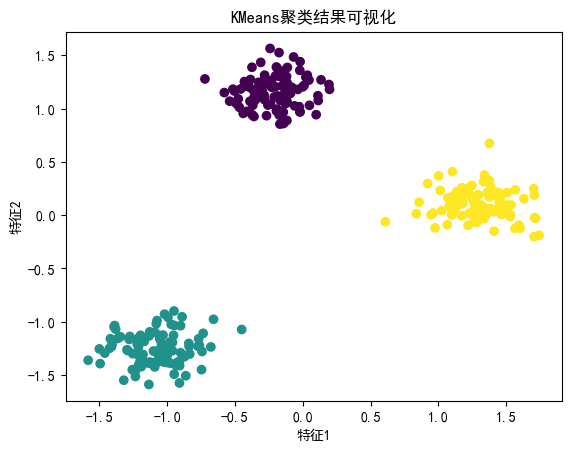

In [34]:
# API介绍：KMeans 聚类算法应用与评估（带详细注释）

# 1. 导包
from sklearn.cluster import KMeans         # KMeans 聚类算法
from sklearn.datasets import make_blobs    # 生成模拟聚类数据
from sklearn.preprocessing import StandardScaler  # 数据标准化处理
from sklearn.metrics import silhouette_score      # 轮廓系数评价指标
from sklearn.metrics import calinski_harabasz_score  # Calinski-Harabasz指数（CH指数）评价聚类质量
import matplotlib.pyplot as plt            # 绘图工具

# 2. 生成模拟聚类数据
#   n_samples: 总样本数（如300条数据）
#   n_features: 特征维度（如2维，适合可视化）
#   centers: 生成数据的聚类中心数量（如3个中心）
#   cluster_std: 每个簇内的标准差（数值越小，簇分得越紧）
#   random_state: 保证结果可复现
X, _ = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=1.0, random_state=42)

# 3. 数据标准化
#   标准化是聚类前常见预处理操作，使每一维特征均值为0、方差为1，消除量纲影响
sd = StandardScaler()
X = sd.fit_transform(X)    # 对X进行标准化

# 4. 创建 KMeans 聚类模型
#   n_clusters: 指定聚类的数量，这里设置为3
#   random_state: 使每次运行初始化一致，结果可复现
kmeans = KMeans(n_clusters=3, random_state=42)

# 5. 训练聚类模型（寻找最佳聚类中心）
kmeans.fit(X)

# 6. 输出每个样本的聚类标签（即属于哪个簇）
labels = kmeans.predict(X)   # 也可用 kmeans.labels_
print(labels)                # 每个数据点所属的簇编号（0...n_clusters-1）

# 7. 模型评估
#   kmeans.inertia_: 簇内平方和误差（SSE），值越小越好
#   silhouette_score: 轮廓系数（[-1,1]，越大聚类效果越好，>0.5通常就不错）
#   calinski_harabasz_score: CH指数，值越大表示聚类越密集、类间分布越分散（越好）
print("簇内平方和SSE:", kmeans.inertia_)
print("轮廓系数:", silhouette_score(X, labels))
print("CH指数:", calinski_harabasz_score(X, labels))

# 8. 聚类结果可视化
#   绘制散点图，每个点根据标签着色，展示聚类效果
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("KMeans聚类结果可视化")
plt.xlabel("特征1")
plt.ylabel("特征2")
plt.show()

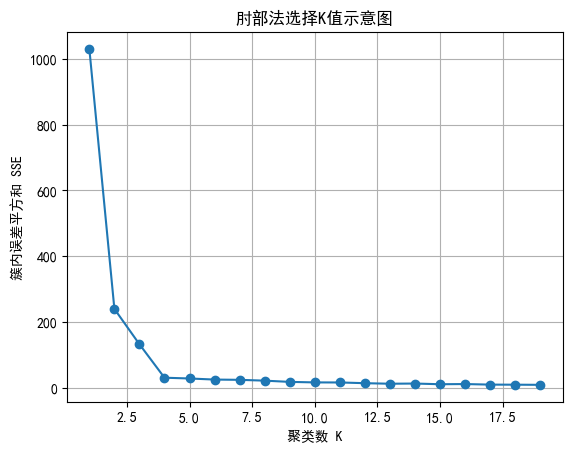

In [35]:
# K-means，使用肘部法确定K值

# 1. 导包
from sklearn.cluster import KMeans           # 导入KMeans聚类算法
from sklearn.datasets import make_blobs      # 导入生成用于聚类的数据集的工具
import matplotlib.pyplot as plt              # 导入绘图工具
import numpy as np                           # 导入numpy用于数值计算

# 2. 创建数据集
# 生成一个包含400个样本、4个特征并分布在4个中心的数据集
# centers参数指定了4个中心的位置，cluster_std控制簇内数据的离散程度
# random_state确保每次运行数据一致，方便复现结果
X, y = make_blobs(n_samples=400, 
                  n_features=4, 
                  centers=[[-1, -1], [0, 0], [1, 1], [2, 2]], 
                  cluster_std=0.2, 
                  random_state=42)
# 若想可视化二维散点图，可使用plt.scatter(X[:,0], X[:,1])，这里只生成数据

# 3. 肘部法确定K值
# 肘部法: 通过观察不同K（聚类数量）下，SSE（簇内误差平方和）的变化来选择最佳K
SSE = []  # 用于保存每个K值对应的SSE
for k in range(1, 20):                   # 遍历K为1到19的情况
    kmeans = KMeans(n_clusters=k)        # 创建KMeans对象，设置聚类中心数量为k
    kmeans.fit(X)                        # 用数据X训练KMeans模型
    SSE.append(kmeans.inertia_)          # inertia_即SSE，表示所有点到最近中心的距离平方和

# 4. 绘制肘部法曲线
# X轴为聚类数量K，Y轴为对应的SSE
# 通常“SSE下降趋于平缓处”对应的K即为最佳聚类数量（肘部位置）
plt.plot(range(1, 20), SSE, marker='o')  # 绘制SSE随K变化的曲线，散点用o标记
plt.xlabel("聚类数 K") 
plt.ylabel("簇内误差平方和 SSE")
plt.title("肘部法选择K值示意图")
plt.grid(True)
plt.show()

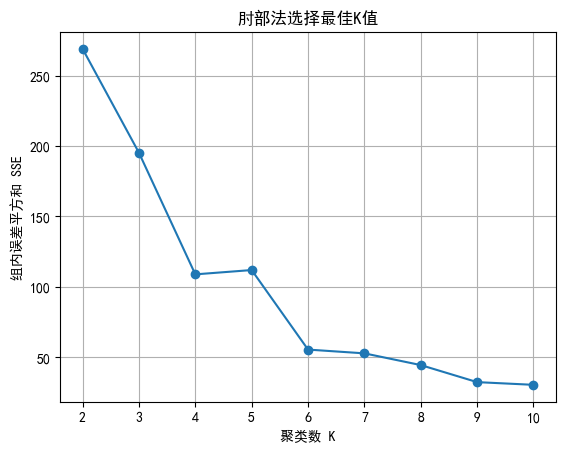

In [36]:
# 聚类，客户分析案例

# 1. 导入必要的库
import numpy as np  # numpy用于数值运算
import pandas as pd  # pandas用于数据读写和处理
import matplotlib.pyplot as plt  # matplotlib用于数据可视化
from sklearn.cluster import KMeans  # KMeans用于进行K均值聚类
from sklearn.preprocessing import StandardScaler  # StandardScaler用于数据归一化
from sklearn.metrics import silhouette_score  # silhouette_score用于计算轮廓系数
from sklearn.metrics import calinski_harabasz_score  # calinski_harabasz_score用于评估聚类效果

# 2. 读取客户数据
# 注意：请确保数据文件路径正确，如'./data/customers.csv'
data = pd.read_csv('data/customers.csv')  # 从本地读取csv数据
data.head()  # 查看数据前5行，确认读取正确

# 3. 选择聚类所需的特征
# 只选取客户年收入和消费得分作为聚类输入
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# 4. 进行特征标准化处理
# 聚类对变量尺度敏感，将数据标准化为均值为0方差为1，避免量纲影响
scaler = StandardScaler()  # 创建标准化对象
X = scaler.fit_transform(X)  # 对数据X进行标准化，并返回标准化后的结果

# 5. 使用肘部法选择最佳聚类数（K值）
# SSE（组内误差平方和）：反映所有点到其中心的距离平方和，K变大SSE变小
# SC（轮廓系数）：评估样本距离本簇和最近簇的紧密离散程度，范围[-1,1]
SSE = []  # 存储不同K下的SSE
SC = []   # 存储不同K下的轮廓系数
for k in range(2, 11):  # 通常聚类数从2到10
    estimator = KMeans(n_clusters=k)  # 创建KMeans聚类器对象，指定聚类中心个数为k
    estimator.fit(X)  # 训练（拟合）数据X，进行聚类
    SSE.append(estimator.inertia_)  # inertia_属性即为当前K下的SSE，加入列表SSE
    SC.append(silhouette_score(X, estimator.labels_))  # 计算聚类标签的轮廓系数，加入列表SC

# 6. 绘制肘部法和轮廓系数图像
# 绘制SSE随K变化的曲线，寻找"SSE大幅下降后趋于平缓的转折点"，作为最佳K
plt.plot(range(2, 11), SSE, 'o-')  # 'o-'指定点线样式
plt.xlabel("聚类数 K")  # x轴为聚类中心数
plt.ylabel("组内误差平方和 SSE")  # y轴为SSE
plt.title("肘部法选择最佳K值")  # 图标题
plt.grid(True)  # 显示网格
plt.show()  # 显示SSE曲线

# 若需观察轮廓系数随K的变化趋势，可以取消下面注释
# plt.plot(range(2, 11), SC, 'o-')  # 绘制轮廓系数曲线
# plt.title("不同K分区下的轮廓系数变化")  # 标题
# plt.xlabel("聚类数 K")  # x轴名称
# plt.ylabel("轮廓系数 Silhouette Coefficient")  # y轴名称
# plt.grid()  # 添加网格线，便于观察
# plt.show()  # 显示SC曲线

In [1]:
import torch
#打印torch版本信息
print(torch.__version__)

2.9.1+cpu


## ========== 线性回归函数方法详解（Linear Regression Functions Explained）==========

### 📚 本案例使用的所有重要函数方法汇总：

| 函数/方法 | 功能 | 语法示例 | 返回值类型 | 详细说明 |
|---------|------|---------|-----------|------|
| **`fetch_california_housing()`** | 获取加州房价数据集 | `fetch_california_housing(data_home='data')` | `Bunch对象` | sklearn内置房价数据集，包含特征和目标 |
| **`pd.DataFrame()`** | 创建DataFrame | `pd.DataFrame(data, columns=names)` | `DataFrame` | pandas数据框，表格形式存储数据 |
| **`train_test_split()`** | 数据集分割 | `train_test_split(X, y, test_size=0.2)` | `4个数组` | 将数据分割为训练集和测试集 |
| **`StandardScaler()`** | 特征标准化 | `StandardScaler()` | `StandardScaler对象` | 将特征标准化为均值0方差1 |
| **`.fit_transform()`** | 拟合并转换 | `scaler.fit_transform(X_train)` | `numpy.ndarray` | 学习参数并应用标准化 |
| **`.transform()`** | 应用转换 | `scaler.transform(X_test)` | `numpy.ndarray` | 使用已学习的参数标准化新数据 |
| **`LinearRegression()`** | 线性回归模型 | `LinearRegression()` | `LinearRegression对象` | 使用正规方程的线性回归 |
| **`.fit()`** | 模型训练 | `model.fit(X_train, y_train)` | `模型对象` | 训练模型找到最优参数 |
| **`.coef_`** | 回归系数 | `model.coef_` | `numpy.ndarray` | 每个特征对应的权重系数 |
| **`.intercept_`** | 截距项 | `model.intercept_` | `float` | 模型的截距（常数项） |
| **`.predict()`** | 模型预测 | `model.predict(X_test)` | `numpy.ndarray` | 对新数据进行预测 |
| **`SGDRegressor()`** | SGD线性回归 | `SGDRegressor(eta0=0.01, penalty='l2')` | `SGDRegressor对象` | 使用梯度下降的线性回归 |
| **`Lasso()`** | Lasso回归 | `Lasso(alpha=0.001)` | `Lasso对象` | L1正则化的线性回归 |
| **`Ridge()`** | Ridge回归 | `Ridge(alpha=0.1)` | `Ridge对象` | L2正则化的线性回归 |
| **`mean_squared_error()`** | 均方误差 | `mean_squared_error(y_true, y_pred)` | `float` | 计算MSE损失 |
| **`PolynomialFeatures()`** | 多项式特征 | `PolynomialFeatures(degree=10)` | `PolynomialFeatures对象` | 生成多项式特征 |
| **`.fit_transform()`** | 拟合并转换多项式 | `poly.fit_transform(X)` | `numpy.ndarray` | 生成多项式特征矩阵 |

### 🔧 关键概念详解：

#### 1. **正规方程 vs 梯度下降**
- **正规方程（Normal Equation）**：`LinearRegression`使用的解析解方法
  - 优点：一次性计算，无需迭代，计算稳定
  - 缺点：计算复杂度高（O(n³)），不适合大数据集
  - 公式：`w = (X^T·X)^(-1)·X^T·y`

- **梯度下降（Gradient Descent）**：`SGDRegressor`使用的迭代优化方法
  - 优点：适合大数据集，可以处理无法放入内存的数据
  - 缺点：需要调参（学习率、迭代次数），可能陷入局部最优
  - 更新公式：`w = w - η·∂Loss/∂w`

#### 2. **正则化（Regularization）**
- **L1正则化（Lasso）**：`α·Σ|w_i|`，产生稀疏解，自动特征选择
- **L2正则化（Ridge）**：`α·Σw_i²`，减小系数方差，防止过拟合
- **ElasticNet**：L1和L2的组合

#### 3. **多项式回归（Polynomial Regression）**
- **原理**：通过多项式特征扩展，将非线性关系转换为线性关系
- **degree参数**：多项式最高次数，值越大模型复杂度越高
- **过拟合风险**：高次多项式容易过拟合，需要正则化

#### 4. **特征标准化（Feature Scaling）**
- **为什么需要**：不同特征的量纲不同会影响模型性能
- **StandardScaler**：`x_scaled = (x - mean) / std`
- **对梯度下降很重要**：不同尺度会导致收敛速度不一致

#### 5. **模型评估指标**
- **MSE（均方误差）**：`Σ(y_pred - y_true)² / n`
  - 优点：对大误差惩罚更大
  - 单位：因变量单位的平方
- **RMSE（均方根误差）**：`√MSE`
  - 优点：与因变量单位相同，便于理解
- **MAE（平均绝对误差）**：`Σ|y_pred - y_true| / n`
  - 优点：对异常值不敏感

### 🎯 模型选择建议：

1. **小数据集**：使用`LinearRegression`（正规方程）
2. **大数据集**：使用`SGDRegressor`（梯度下降）
3. **特征选择**：使用`Lasso`（L1正则化）
4. **防止过拟合**：使用`Ridge`（L2正则化）
5. **非线性关系**：使用多项式特征 + Ridge回归

### 📊 代码执行流程：

1. **数据获取** → `fetch_california_housing()`
2. **数据预处理** → `StandardScaler().fit_transform()`
3. **数据集分割** → `train_test_split()`
4. **模型训练** → `model.fit(X_train, y_train)`
5. **模型预测** → `model.predict(X_test)`
6. **模型评估** → `mean_squared_error(y_test, y_pred)`

这个案例展示了从数据准备到模型评估的完整线性回归流程，包括多种算法的对比和多项式回归的应用。